In [1]:
# -------------------------------------------------------------
# Common pre‑amble – read config & export core variables
# -------------------------------------------------------------

from pathlib import Path
import os, sys

# infer repo root from the location of this file
repo_root = os.path.abspath('..')
sys.path.insert(0, str(repo_root))  # allow `import src.*`
from config.notebook_setup import *

Repository Root: /home/marcmaceira/projects/reuters-rag-classifier_clean_v2
Configuration: {'general': {'run_name': 'experiment_with_4_classes', 'seed': 42}, 'dataset': {'split_type': 'test', 'n_classes': 5, 'n_samples_per_class': 10}, 'paths': {'data_exploration_dir': 'output/experiment_with_4_classes/data_exploration', 'embeddings_dir': 'output/experiment_with_4_classes/embeddings', 'models_dir': 'output/experiment_with_4_classes/models', 'predictions_dir': 'output/experiment_with_4_classes/predictions', 'results_dir': 'output/experiment_with_4_classes/results'}, 'model': {'embedding_backend': 'sbert', 'sbert_model_name': 'sentence-transformers/all-MiniLM-L12-v2', 'openai_model_name': 'text-embedding-3-small', 'classifier': 'linear_svm', 'rag_top_k': 5, 'use_llm_refine': False}, 'training': {'batch_size': 32, 'max_epochs': 10, 'learning_rate': '1e-3'}, 'evaluation': {'metrics': ['accuracy', 'macro_f1', 'auc_ovr']}}

=== Configuration Variables ===

[DATASET]
  DATASET_N_CLASSES: 5
  

# Reuters News Topic Classification - Data Loading

This notebook handles the initial data loading and preprocessing for the Reuters news topic classification task. We'll be using the Reuters-21578 corpus, a classic dataset of Reuters newswire articles labeled with economic topics.

## Dataset Overview

The Reuters-21578 corpus is a collection of 10,788 Reuters newswire articles that have been labeled with economic topics. Key features:

* Open license - freely redistributable for research/commercial use
* Rich, domain-specific text - financial and commodities news
* Benchmark pedigree - allows comparison against decades of literature

## Setup and Imports

In [2]:
import logging
import warnings
from src.datasets.dataset import get_dataset

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

## Load Dataset

We'll load the top 10 topics for clarity in our classification task.

In [3]:

# Load dataset
# X_train, y_train, _, _, _ = get_dataset(split_type="standard", n_classes=N_CLASSES)
X_train, y_train, X_test, y_test, classes = get_dataset(
    split_type=DATASET_SPLIT_TYPE,
    n_classes=N_CLASSES,
    n_samples_per_class=N_SAMPLES_PER_CLASS,
)

print(f"Loaded {len(X_train)} training documents with {N_CLASSES} classes")


INFO | Loading Reuters dataset with configuration:
INFO |   - Split type: test
INFO |   - Number of classes: 5
INFO |   - Samples per class: 10
INFO |   - Random seed: None
INFO | Loading small test dataset with 10 samples per class across 5 classes
INFO | Selected classes: earn, acq, crude, interest, money-fx
INFO |   - Class 'earn': 7 train, 3 test
INFO |   - Class 'acq': 7 train, 3 test
INFO |   - Class 'crude': 7 train, 3 test
INFO |   - Class 'interest': 7 train, 3 test
INFO |   - Class 'money-fx': 7 train, 3 test


Loaded 35 training documents with 5 classes


## Data Exploration

Let's examine the distribution of classes and article lengths to understand our dataset better.

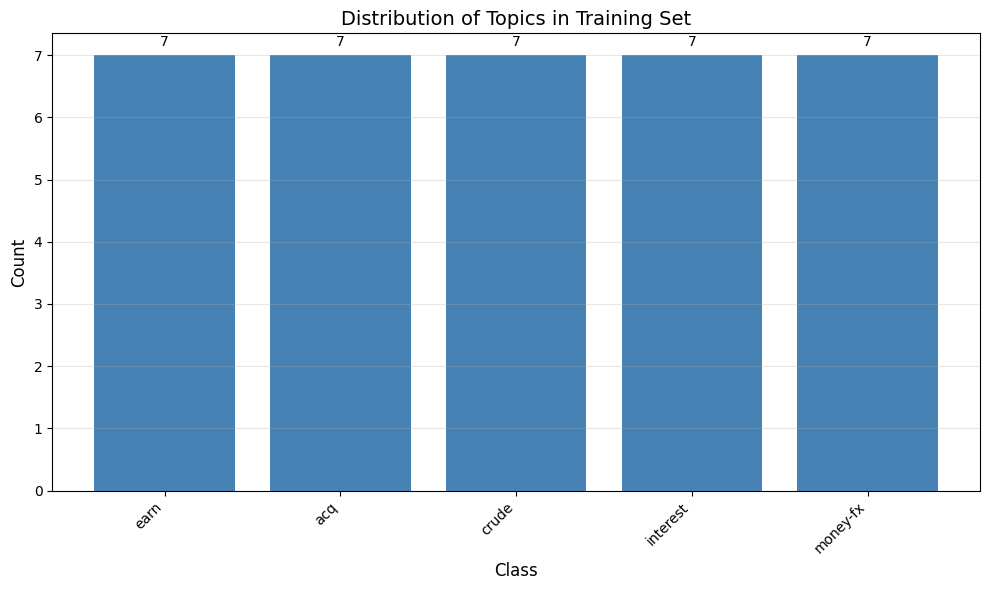

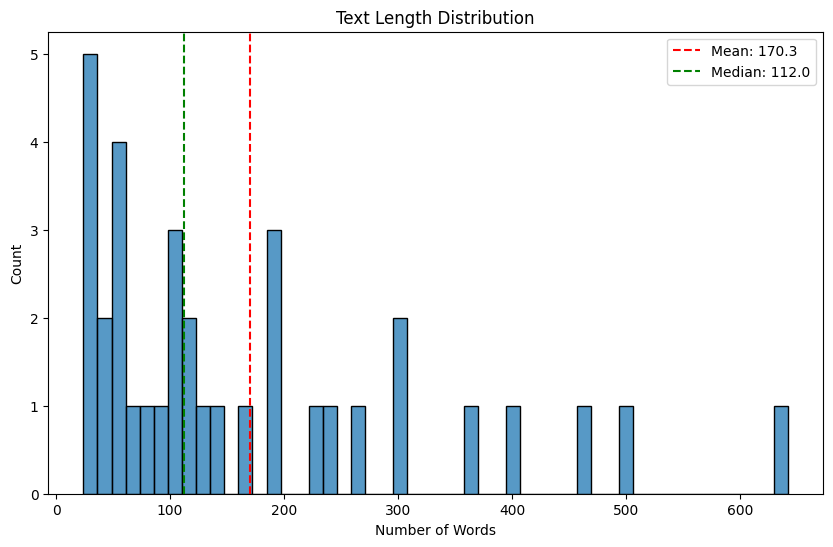

Mean length: 170.3 tokens, median: 112.0


In [4]:
from src.exploration import class_frequency, length_distribution
import pandas as pd


# Imbalance plot
class_frequency(y_train, top_n=20)

# Article length distribution
stats = length_distribution(X_train)
print(f"Mean length: {stats['stats']['mean']:.1f} tokens, median: {stats['stats']['median']}")